# mixed layer depth

In [5]:
using JLD2
using Plots
using Statistics
using Printf

gr()
default(size=(900, 500), linewidth=2)

const ROOT = normpath(joinpath(@__DIR__, ".."))
const SITES = ["lat30lon-50", "lat-25lon-10", "lat-45lon80", "lat0lon-140", "lat30lon-150", "lat40lon-25"]

function mld_depth(T_profile, z; ΔT=0.2)
    T_surf = T_profile[1]
    thr = T_surf - ΔT
    for i in 2:length(T_profile)
        if T_profile[i] <= thr
            t1, t2 = T_profile[i-1], T_profile[i]
            z1, z2 = z[i-1], z[i]
            t1 == t2 && return z1
            frac = (thr - t1) / (t2 - t1)
            return z1 + frac * (z2 - z1)
        end
    end
    grads = abs.(diff(T_profile) ./ diff(z))
    idx = argmax(grads)
    return 0.5 * (z[idx] + z[idx+1])
end

mld_depth (generic function with 1 method)

In [6]:
function site_mlds(site::String)
    qt_f = joinpath(ROOT, "output/era5/ml_forced_30day_v2_qt_$(site).jld2")
    noqt_f = joinpath(ROOT, "output/era5/ml_forced_30day_v2_noqt_$(site).jld2")
    gly_f = site == "lat30lon-50" ?
        joinpath(ROOT, "data/generated/glorys_processed.jld2") :
        joinpath(ROOT, "data/generated/glorys_processed_$(site).jld2")

    (isfile(qt_f) && isfile(gly_f)) || return nothing
    qt = JLD2.load(qt_f)
    noqt = isfile(noqt_f) ? JLD2.load(noqt_f) : nothing
    gly = JLD2.load(gly_f)

    vert_res = length(qt["T_profiles"][1])
    z = collect(range(0, stop=100, length=vert_res))
    t = qt["saved_times"] ./ 86400
    N = min(length(qt["T_profiles"]), length(gly["T_profiles"]))

    mld_qt   = [mld_depth(reverse(qt["T_profiles"][i]), z) for i in 1:N]
    mld_noqt = noqt === nothing ? fill(NaN, N) : [mld_depth(reverse(noqt["T_profiles"][i]), z) for i in 1:N]
    mld_gly  = [mld_depth(gly["T_profiles"][i], z) for i in 1:N]

    return (t=t[1:N], qt=mld_qt, noqt=mld_noqt, gly=mld_gly)
end

site_mlds (generic function with 1 method)

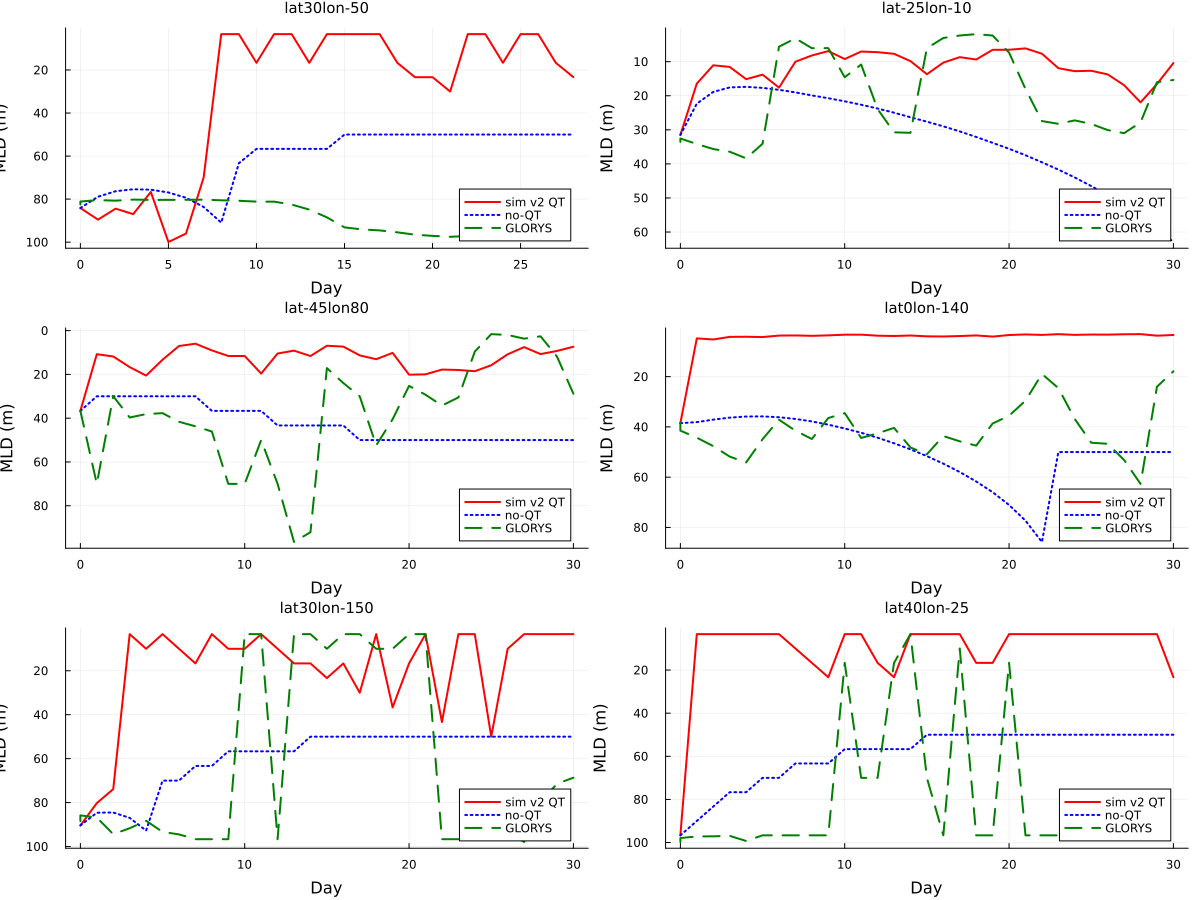

In [7]:
function plot_site_mld(site::String)
    m = site_mlds(site)
    m === nothing && return nothing
    p = plot(xlabel="Day", ylabel="MLD (m)", title=site, yflip=true, legend=:bottomright, titlefontsize=10)
    plot!(p, m.t, m.qt, label="sim v2 QT", color=:red)
    plot!(p, m.t, m.noqt, label="no-QT", color=:blue, linestyle=:dot)
    plot!(p, m.t, m.gly, label="GLORYS", color=:green, linestyle=:dash)
    return p
end

plot([plot_site_mld(s) for s in SITES if site_mlds(s) !== nothing]...,
     layout=(3,2), size=(1200, 900))

## MLD skill table

In [8]:
function corr(x, y)
    μx, μy = mean(x), mean(y)
    σx, σy = std(x), std(y)
    (σx == 0 || σy == 0) && return NaN
    return mean((x .- μx) .* (y .- μy)) / (σx * σy)
end

println(rpad("site", 14), " | ", rpad("mean sim", 12), rpad("mean GLY", 12), rpad("RMSE (m)", 12), "corr")
println("-" ^ 60)
for site in SITES
    m = site_mlds(site)
    m === nothing && continue
    rmse = sqrt(mean((m.qt .- m.gly).^2))
    c = corr(m.qt, m.gly)
    @printf("%-14s | %-12.1f %-12.1f %-12.1f %.3f\n",
            site, mean(m.qt), mean(m.gly), rmse, c)
end

site           | mean sim    mean GLY    RMSE (m)    corr
------------------------------------------------------------
lat30lon-50    | 33.2         87.7         67.7         -0.568
lat-25lon-10   | 12.5         20.3         13.7         0.424
lat-45lon80    | 14.0         37.9         35.1         -0.062
lat0lon-140    | 5.9          41.1         37.6         -0.016
lat30lon-150   | 21.9         61.4         60.0         0.156
lat40lon-25    | 12.9         81.3         77.0         0.138
